In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

df = pd.read_csv('../data/df-prepared.csv')

In [2]:
df['Cargo type'].value_counts()

Cargo type
No additional information    456001
Category X                    43039
Reserved for future use       10042
Category Y                     7272
Category OS                    3693
Category Z                     2587
Name: count, dtype: int64

https://datalastic.com/blog/the-different-hazard-levels-through-ship-api/

- Category X - Pavojingas, sprogus krovinys (which applies to Large pressure vessels (e.g. 4000-tonne ethane vessels, 7000-tonne butane or propane vessels, 25 000 tonne ammonia vessels, 200-tonne chlorine vessels, and large power boilers))
- Category Y - Transporto priemonės ir šildytuvai (boilers)
- Category Z ir OS - Maža ir mažo slėgio įranga
- No additional information - nėra pavojau
- Reserved for future use - nepakrautas laivas

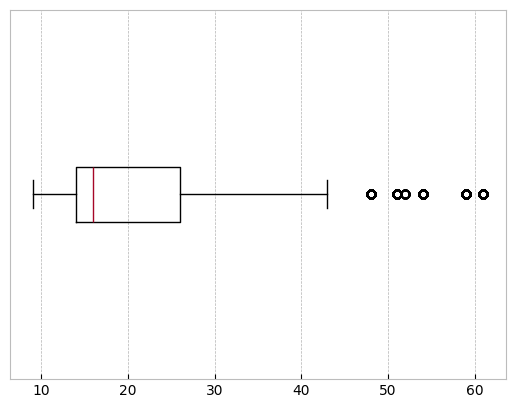

In [3]:
plt.boxplot(df['Width'], orientation='horizontal')
plt.yticks(ticks=[], labels=[])
plt.show()

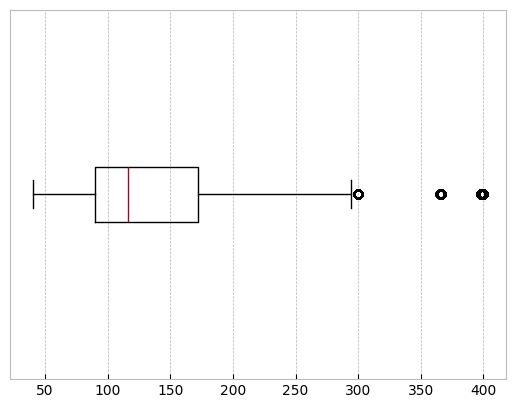

In [4]:
plt.boxplot(df['Length'], orientation='horizontal')
plt.yticks(ticks=[], labels=[])
plt.show()

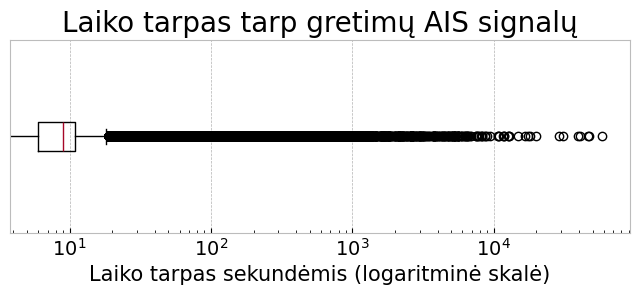

In [5]:
import numpy as np

gaps = np.load('../output/gaps.npy')
gaps = gaps[ ~np.isnan(gaps) ] * 60

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.boxplot( gaps, orientation='horizontal' )
ax.set_xscale('log')

ax.set_xlabel('Laiko tarpas sekundėmis (logaritminė skalė)', fontdict={"size": 15})
ax.tick_params(axis='x', labelsize=14)
ax.set_yticks(ticks=[], labels=[])

ax.set_title('Laiko tarpas tarp gretimų AIS signalų', fontdict={"size": 20})

plt.savefig("laiko-tarpas.png", dpi=750)
plt.show()

In [6]:
df.columns

Index(['SOG', 'COG', 'Cargo type', 'Width', 'Length', 'currentSpeed', 'gust',
       'swellHeight', 'waveHeight', 'windSpeed', 'COG_vec_x', 'COG_vec_y',
       'currentDirection_vec_x', 'currentDirection_vec_y',
       'swellDirection_vec_x', 'swellDirection_vec_y', 'waveDirection_vec_x',
       'waveDirection_vec_y', 'windDirection_vec_x', 'windDirection_vec_y',
       'COG-dif', 'delta_dif', 'MMSI', 'day'],
      dtype='str')

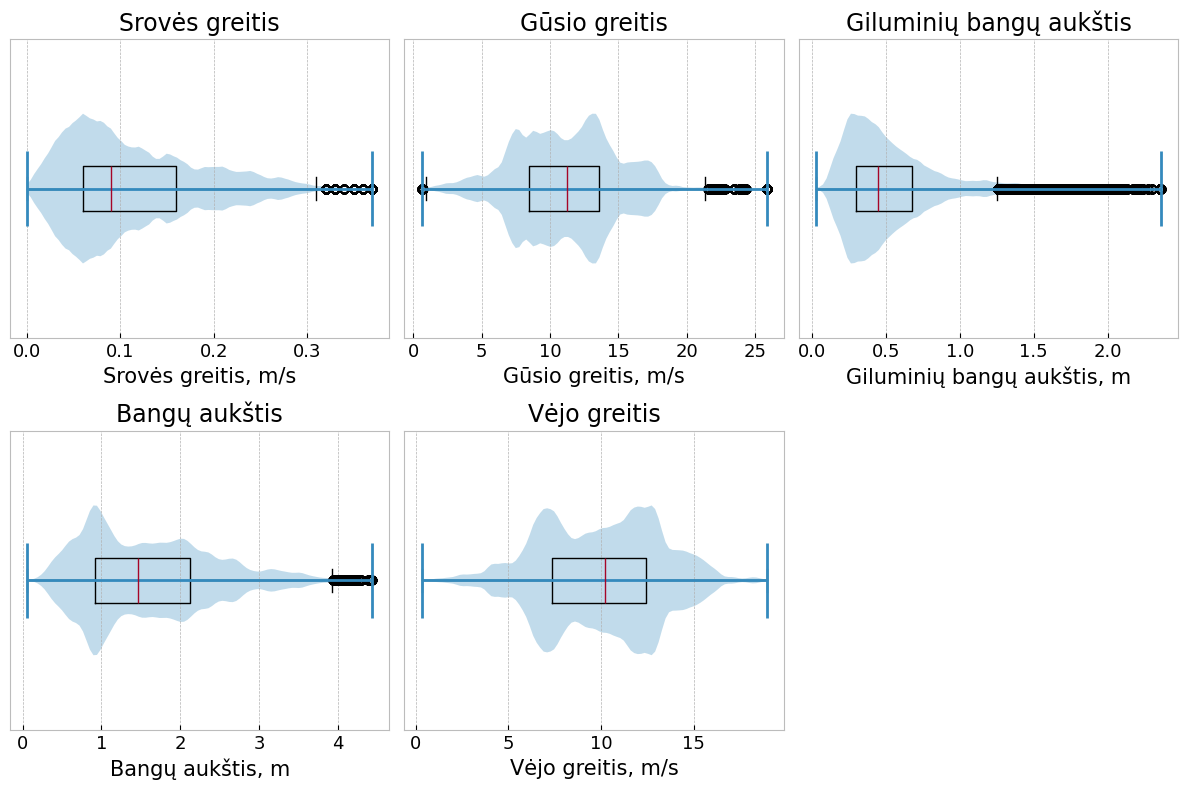

In [7]:
svarbus_kintamieji = {
    # 'SOG': ('Greitis', 'm/s'),
    # 'COG': 'Kursas virš žemės',
    # 'Cargo type': 'Krovinio tipas',
    # 'Width': 'Plotis',
    # 'Length': 'Ilgis',
    'currentSpeed': ('Srovės greitis', 'm/s'),
    'gust': ('Gūsio greitis', 'm/s'),
    'swellHeight': ('Giluminių bangų aukštis', 'm'),
    'waveHeight': ('Bangų aukštis', 'm'),
    'windSpeed': ('Vėjo greitis', 'm/s')
    # 'COG-dif': 'COG pokytis',
    # 'delta_dif': '$dif$ pokytis'
}

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
plt.subplots_adjust(hspace=0.5)

for ix, ax in enumerate(axs.ravel()):
    if ix >= len(svarbus_kintamieji.items()):
        ax.axis('off')
        continue

    kint, (kint_lt, unit) = list( svarbus_kintamieji.items() )[ix]
    ax.boxplot( df[kint], orientation='horizontal' )
    ax.violinplot( df[kint], orientation='horizontal' )
    ax.tick_params(axis='x', labelsize=13)
    ax.set_yticks([])
    ax.set_title(kint_lt, size=17)
    ax.set_xlabel(f'{kint_lt}, {unit}', fontsize=15)

plt.tight_layout()
plt.savefig('meteorologiniai-kintamieji.png', dpi=750)
plt.show()

In [8]:
q1, q3 = np.quantile(gaps, q=[0.05, 0.95])
q1, q3

(np.float64(2.0), np.float64(20.0))

In [9]:
import seaborn as sns

In [10]:
df.columns

Index(['SOG', 'COG', 'Cargo type', 'Width', 'Length', 'currentSpeed', 'gust',
       'swellHeight', 'waveHeight', 'windSpeed', 'COG_vec_x', 'COG_vec_y',
       'currentDirection_vec_x', 'currentDirection_vec_y',
       'swellDirection_vec_x', 'swellDirection_vec_y', 'waveDirection_vec_x',
       'waveDirection_vec_y', 'windDirection_vec_x', 'windDirection_vec_y',
       'COG-dif', 'delta_dif', 'MMSI', 'day'],
      dtype='str')

In [ ]:
numeric_cols ={
    'SOG': 'Greitis virš žemės',
    'COG': 'Kursas virš žemės',
    # 'Width',
    # 'Length',
    'currentSpeed': 'Srovės greitis',
    'gust': 'Gūsio greitis',
    'swellHeight': 'Giluminių bangų aukštis',
    'waveHeight': 'Bangų aukštis',
    'COG-dif': 'COG pokytis',
    'delta_dif': '$dif$ pokytis'
} 

sns.pairplot(df[ list(numeric_cols.keys()) + ['Cargo type']], hue='Cargo type', plot_kws={'alpha': 0.5})

plt.xticks(ticks=range(len(numeric_cols)), labels=numeric_cols.values(), rotation=90)
plt.yticks(ticks=range(len(numeric_cols)), labels=numeric_cols.values())

plt.show()

KeyboardInterrupt: 